# Protein Folding Checkpoint Training

This notebook trains the small atom-level `ProteinFolding` model after the PLM checkpoint exists. It uses the same cached structure shards as the explainer notebook, loads and freezes `protein_lm.pt`, trains the folding modules on atom-coordinate supervision, and saves `protein_folding_folding.pt` for the next stage.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, display

from model.protein_folding import (
    ATOM_SLOTS,
    ProteinDataLoaderLite,
    ProteinFolding,
    ProteinFoldingConfig,
    centered_gaussian_noise,
    folding_model_inputs,
    sample_log_uniform_sigmas,
    write_atom_pdb,
)
from model.protein_tokenizer import ProteinTokenizer


## Devices & Paths

We keep the same data and checkpoint layout as `train_plm.ipynb`. The folding checkpoint depends on the Stage 1 PLM checkpoint, so run `train_plm.ipynb` first.


In [2]:
SEED = 1337

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
print(f'using {device}')

data_root = Path('~/data/protein_folding').expanduser()
shard_path = data_root / 'tokenized'
plm_checkpoint_path = data_root / 'checkpoint' / 'protein_lm.pt'
folding_checkpoint_path = data_root / 'checkpoint' / 'protein_folding_folding.pt'
frame_dir = data_root / 'folding_epoch_frames'
pdb_dir = data_root / 'folding_epoch_pdbs'
folding_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
frame_dir.mkdir(parents=True, exist_ok=True)
pdb_dir.mkdir(parents=True, exist_ok=True)

using cpu


## Setup

The loader reads full structure batches, not sequence-only batches. It starts from the cached slot-shaped structure fields and returns the flattened atom-token fields that `ProteinFolding.forward` expects: reference atom positions, atom masks, atom identity features, atom-to-token indices, token metadata, token bonds, and representative atoms for distogram supervision.

In [3]:
batch_size = 2
epochs = 25
lr = 3e-4
weight_decay = 0.01
sample_steps = 12


In [4]:
def count_split_examples(root, split):
    total = 0
    for path in sorted((root / split).glob('*.npz')):
        with np.load(path, allow_pickle=False) as shard:
            total += int(shard['input_ids'].shape[0])
    return total

train_examples = count_split_examples(shard_path, 'train')
val_examples = count_split_examples(shard_path, 'val')
steps_per_epoch = (train_examples + batch_size - 1) // batch_size
val_steps = (val_examples + batch_size - 1) // batch_size
max_steps = epochs * steps_per_epoch

print(f'train examples: {train_examples:,}')
print(f'val examples: {val_examples:,}')
print(f'steps per epoch: {steps_per_epoch:,}')
print(f'total steps: {max_steps:,}')


train examples: 113
val examples: 14
steps per epoch: 57
total steps: 1,425


In [5]:
train_loader = ProteinDataLoaderLite(
    shard_path,
    batch_size,
    block_size=64,
    split='train',
    seed=SEED,
)
val_loader = ProteinDataLoaderLite(
    shard_path,
    batch_size,
    block_size=64,
    split='val',
    seed=SEED + 1,
)
tokenizer = ProteinTokenizer()


## Model

The folding model reconstructs its embedded PLM from the Stage 1 checkpoint configuration, then loads those PLM weights and freezes them. The trainable path is the folding stack around it: input embedding, LM pair shim, pair initialization, recycling trunk, distogram head, structure denoiser, and confidence head.


In [6]:
plm_checkpoint = torch.load(plm_checkpoint_path, map_location=device)
plm_config = plm_checkpoint['config']
plm_config

{'vocab_size': 64,
 'context_size': 64,
 'embed_dim': 128,
 'lm_heads': 8,
 'lm_layers': 6,
 'mlm_mask_probability': 0.15,
 'dropout': 0.1}

In [7]:
folding_cfg = ProteinFoldingConfig(
    block_size=64,
    vocab_size=64,
    res_type_vocab_size=33,
    lm_dim=plm_config['embed_dim'],
    lm_layers=plm_config['lm_layers'],
    lm_heads=plm_config['lm_heads'],
    single_dim=96,
    pair_dim=64,
    atom_dim=48,
    atom_encoder_layers=2,
    atom_encoder_heads=4,
    atom_attention_window=32,
    diffusion_heads=4,
    pair_layers=4,
    recycle_loops=2,
    relative_position_bins=16,
    relative_chain_bins=2,
    time_dim=32,
    denoiser_layers=4,
    distance_rbf_bins=16,
    distogram_bins=32,
    plddt_bins=50,
    pae_bins=32,
    pde_bins=32,
    sigma_min=0.1,
    sigma_max=20.0,
    sigma_data=10.0,
    sampling_steps=12,
    confidence_rollout_steps=4,
    confidence_rollout_interval=4,
    mlm_mask_probability=plm_config.get('mlm_mask_probability', 0.15),
    dropout=0.05,
)
folding_cfg


ProteinFoldingConfig(block_size=64, vocab_size=64, res_type_vocab_size=33, lm_dim=128, lm_layers=6, lm_heads=8, single_dim=96, pair_dim=64, atom_dim=48, atom_encoder_layers=2, atom_encoder_heads=4, atom_attention_window=32, diffusion_heads=4, pair_layers=4, recycle_loops=2, relative_position_bins=16, relative_chain_bins=2, time_dim=32, denoiser_layers=4, distance_rbf_bins=16, distogram_bins=32, plddt_bins=50, pae_bins=32, pde_bins=32, sigma_min=0.1, sigma_max=20.0, sigma_data=10.0, sampling_steps=12, confidence_rollout_steps=4, confidence_rollout_interval=4, mlm_mask_probability=0.15, dropout=0.05)

In [8]:
model = ProteinFolding(folding_cfg).to(device)
model.protein_lm.load_state_dict(plm_checkpoint['model'])
for parameter in model.protein_lm.parameters():
    parameter.requires_grad = False
model.protein_lm.eval()

optimizer = torch.optim.AdamW(
    [parameter for parameter in model.parameters() if parameter.requires_grad],
    lr=lr,
    weight_decay=weight_decay,
)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
trainable_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f'parameters: {parameter_count:,}')
print(f'trainable:  {trainable_count:,}')


parameters: 3,692,146
trainable:  2,082,354


## Example Structure Snapshot

At the end of each epoch, we run the sampler on one fixed validation example and save two artifacts: a predicted atom-level PDB and a PNG frame. The sampler uses the same fixed seed every epoch, so the frames are easier to read as training progress instead of a new random starting point each time. The PNG frames are intentionally simple, with the target atoms in gray and the sampled prediction in blue, so they can be stitched into a training-progress GIF.


In [9]:
sample_batch = val_loader.next_batch(device)
val_loader.reset()

sample_length = int(sample_batch['residue_mask'][0].sum().item())
sample_sequence = tokenizer.decode(sample_batch['input_ids'][0, :sample_length].detach().cpu())
atom_count = len(ATOM_SLOTS)

target_atom_coords = sample_batch['atom_coords'][0].view(folding_cfg.block_size, atom_count, 3)[:sample_length]
target_atom_mask = sample_batch['atom_mask'][0].view(folding_cfg.block_size, atom_count)[:sample_length]
write_atom_pdb(pdb_dir / 'target.pdb', target_atom_coords, target_atom_mask, sample_sequence)

sample_sequence, sample_length, target_atom_mask.sum()


('RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFKSAEDAMRTCGGA', 58, tensor(454))

In [10]:
def set_equal_3d_axes(ax, points):
    points = points.detach().cpu()
    center = points.mean(dim=0)
    span = (points.max(dim=0).values - points.min(dim=0).values).max().item()
    radius = max(span * 0.6, 1.0)
    ax.set_xlim(float(center[0] - radius), float(center[0] + radius))
    ax.set_ylim(float(center[1] - radius), float(center[1] + radius))
    ax.set_zlim(float(center[2] - radius), float(center[2] + radius))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])


def save_epoch_structure_frame(epoch):
    model.eval()
    model.protein_lm.eval()
    with torch.no_grad():
        sample_output = model.sample(
            **folding_model_inputs(sample_batch),
            num_steps=sample_steps,
            seed=SEED + 20_000,
        )

    predicted_atom_coords = sample_output['atom_coords'][0].view(folding_cfg.block_size, atom_count, 3)[:sample_length]
    predicted_atom_mask = target_atom_mask
    predicted_confidence = sample_output['predicted_plddt'][0, :sample_length]

    pdb_path = pdb_dir / f'epoch_{epoch:03d}.pdb'
    frame_path = frame_dir / f'epoch_{epoch:03d}.png'
    write_atom_pdb(
        pdb_path,
        predicted_atom_coords,
        predicted_atom_mask,
        sample_sequence,
        confidence=predicted_confidence,
    )

    target_points = target_atom_coords[target_atom_mask].detach().cpu()
    predicted_points = predicted_atom_coords[predicted_atom_mask].detach().cpu()
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(
        target_points[:, 0],
        target_points[:, 1],
        target_points[:, 2],
        s=8,
        c='lightgray',
        alpha=0.45,
        depthshade=False,
        label='target',
    )
    ax.scatter(
        predicted_points[:, 0],
        predicted_points[:, 1],
        predicted_points[:, 2],
        s=10,
        c='tab:blue',
        alpha=0.9,
        depthshade=False,
        label='prediction',
    )
    set_equal_3d_axes(ax, torch.cat([target_points, predicted_points], dim=0))
    ax.set_title(f'epoch {epoch:03d} | mean pLDDT {float(predicted_confidence.mean()):.2f}')
    ax.legend(loc='upper right')
    plt.tight_layout()
    fig.savefig(frame_path, dpi=130)
    plt.close(fig)
    return frame_path, pdb_path


## Train

Each step runs the full folding forward pass with atom-coordinate targets. The loss is the Stage 2 folding objective exposed by `ProteinFolding.forward`: diffusion coordinate loss, representative-atom pair-distance loss, distogram cross-entropy, and confidence supervision. After every epoch we validate with the same held-out examples and the same diffusion corruption, save one 12-step sampled structure frame, and return the model to training mode with the PLM still frozen in eval mode.


In [11]:
loss_history = []
component_history = []
val_history = []
frame_history = []
train_loss_total = 0.0
train_component_total = {
    'diffusion': 0.0,
    'distance': 0.0,
    'distogram': 0.0,
    'confidence': 0.0,
}
model.train()
model.protein_lm.eval()


ProteinLM(
  (token_embedding): Embedding(64, 128, padding_idx=1)
  (blocks): ModuleList(
    (0-5): 6 x ProteinTransformerBlock(
      (attention_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attention): ProteinSelfAttention(
        (qkv): Linear(in_features=128, out_features=384, bias=False)
        (output): Linear(in_features=128, out_features=128, bias=False)
        (dropout): Dropout(p=0.05, inplace=False)
        (query_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (key_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (rope): RotaryPositionEmbedding()
      )
      (mlp_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): ProteinMLP(
        (fc): Linear(in_features=128, out_features=1024, bias=False)
        (projection): Linear(in_features=512, out_features=128, bias=False)
      )
    )
  )
  (final_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (sequence_head): Sequential(
 

epoch  1 | train loss 9.9458 | val loss 17.8477 | diff 8.0744 | dist 1.9357 | dgram 3.2930 | conf 2.4494


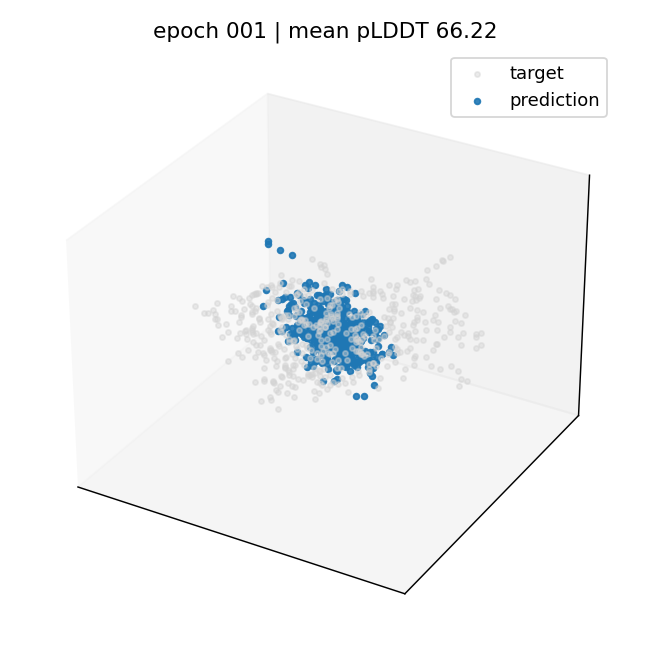

epoch  2 | train loss 13.8866 | val loss 11.8216 | diff 11.9088 | dist 2.2075 | dgram 3.2093 | conf 2.3216


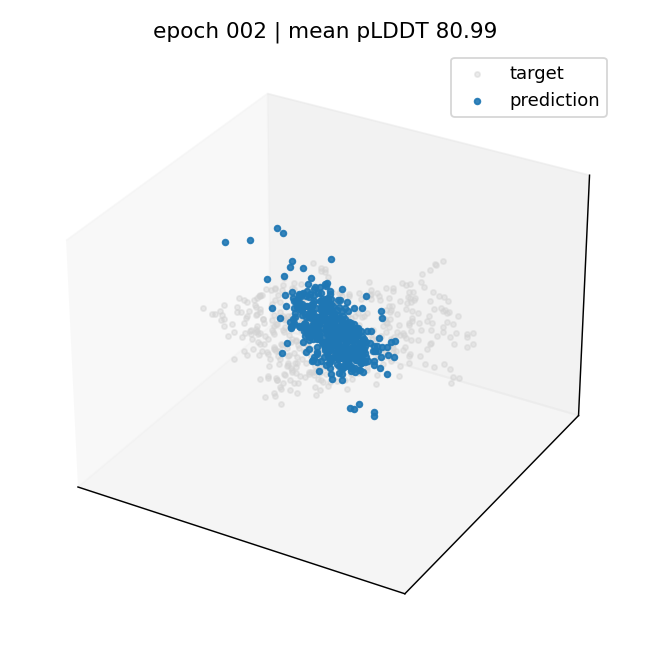

epoch  3 | train loss 9.2352 | val loss 9.3498 | diff 7.5912 | dist 1.6014 | dgram 3.1990 | conf 2.0355


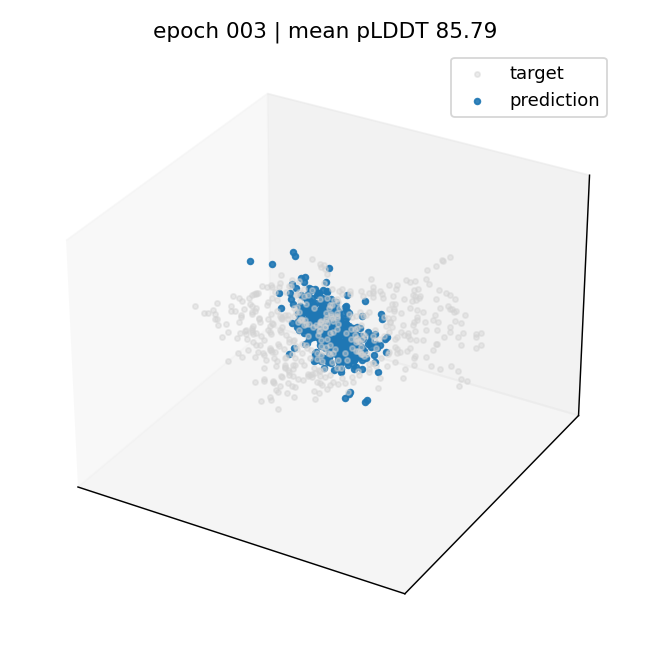

epoch  4 | train loss 6.5437 | val loss 7.6654 | diff 5.0103 | dist 1.3952 | dgram 3.1644 | conf 2.0290


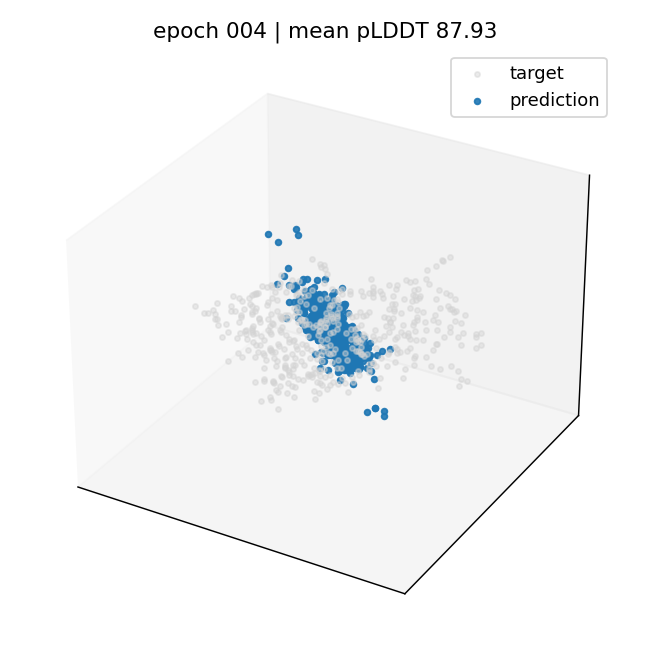

epoch  5 | train loss 7.9499 | val loss 8.3618 | diff 6.3085 | dist 1.5884 | dgram 3.1486 | conf 2.1755


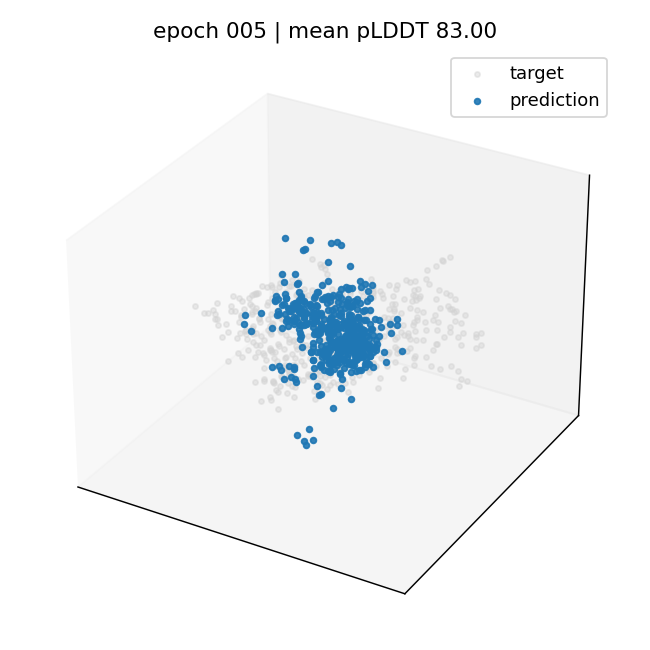

epoch  6 | train loss 5.7118 | val loss 6.5493 | diff 4.2408 | dist 1.3023 | dgram 3.1323 | conf 1.9336


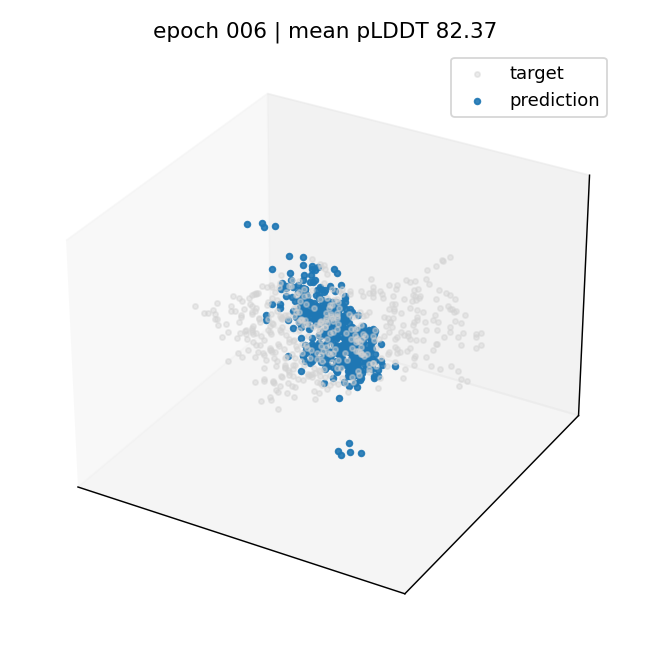

epoch  7 | train loss 6.8331 | val loss 6.8531 | diff 5.3277 | dist 1.3490 | dgram 3.1660 | conf 1.9771


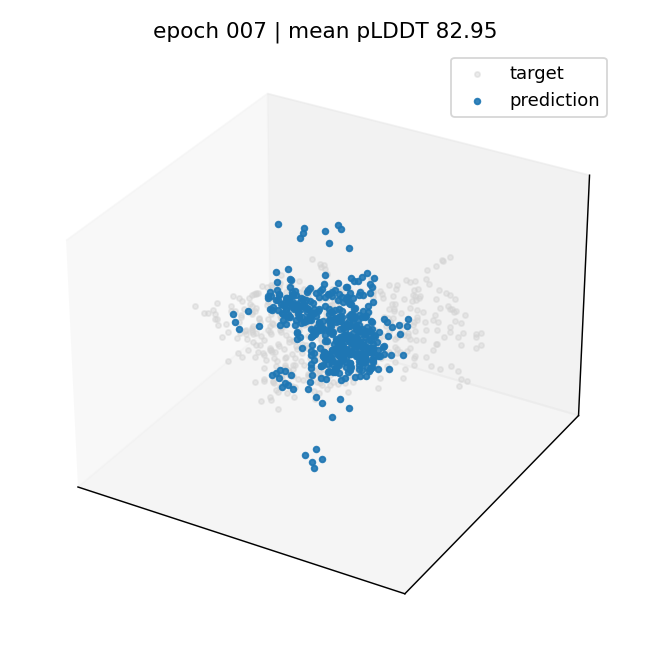

epoch  8 | train loss 6.2853 | val loss 6.4982 | diff 4.7387 | dist 1.4205 | dgram 3.1296 | conf 2.1042


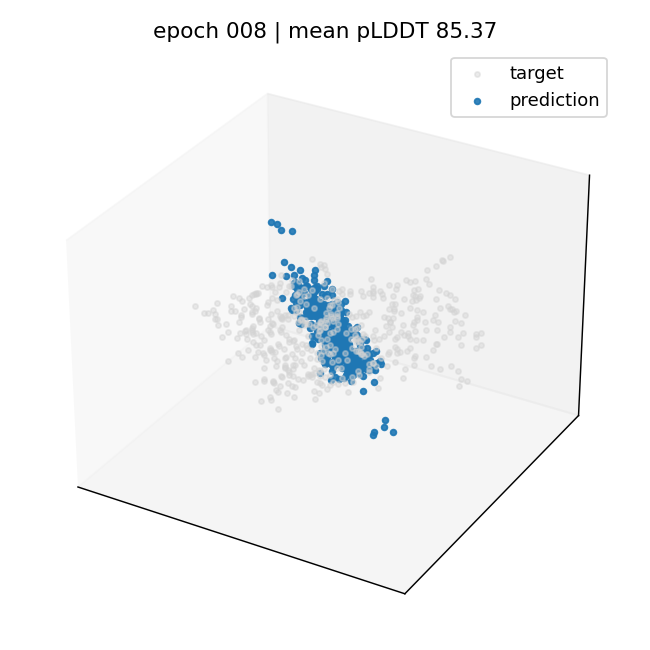

epoch  9 | train loss 6.5837 | val loss 6.6212 | diff 5.1307 | dist 1.2956 | dgram 3.0496 | conf 1.9527


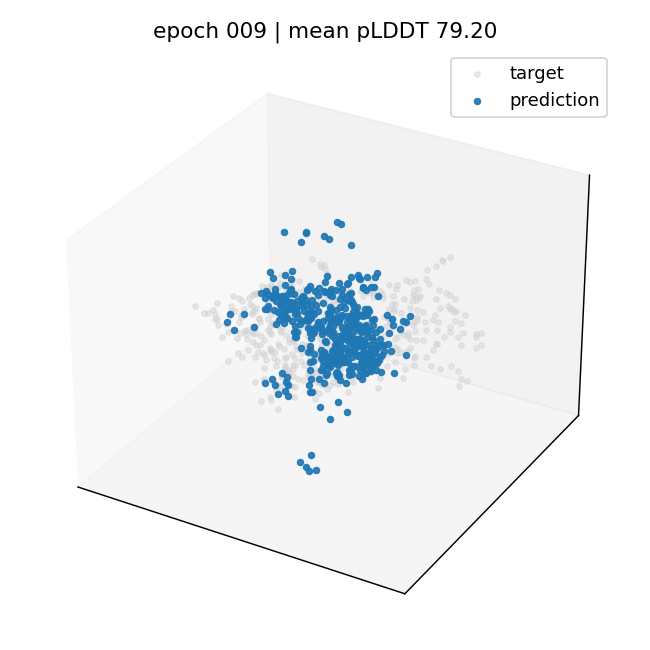

epoch 10 | train loss 6.3867 | val loss 6.5974 | diff 4.8773 | dist 1.4111 | dgram 2.9875 | conf 2.0638


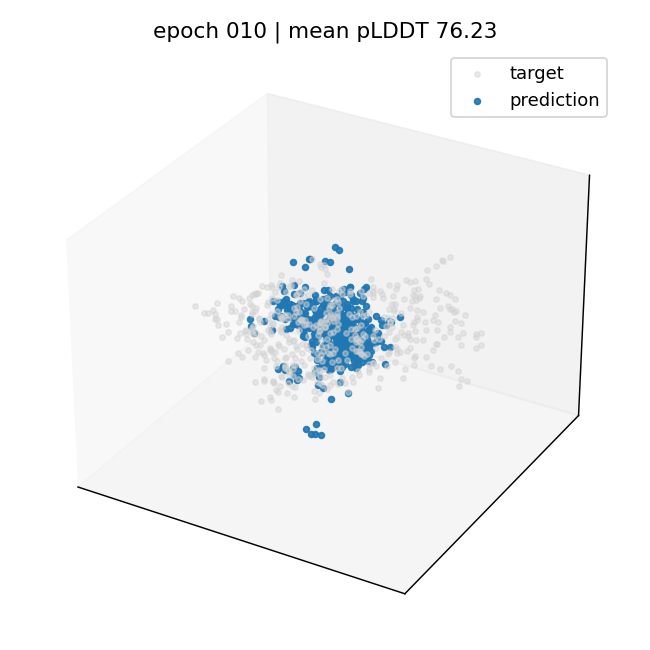

epoch 11 | train loss 7.2831 | val loss 6.3598 | diff 5.6665 | dist 1.6342 | dgram 2.9343 | conf 2.1259


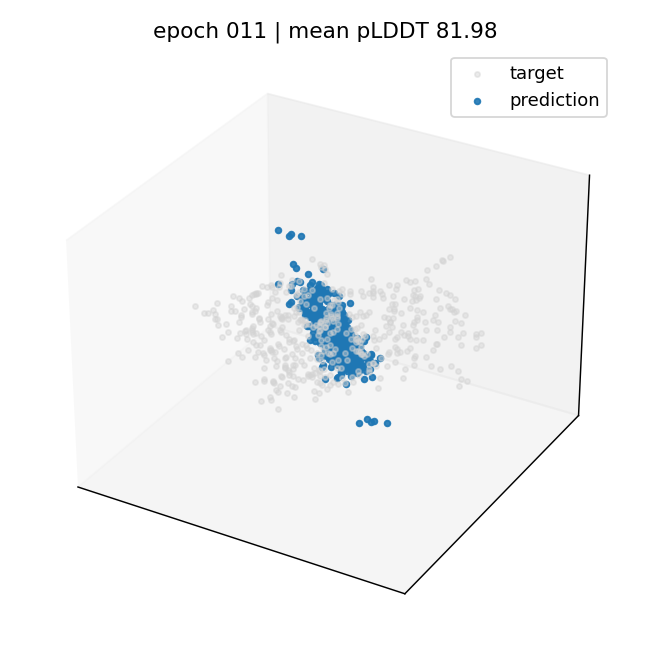

epoch 12 | train loss 5.3311 | val loss 6.3626 | diff 4.0009 | dist 1.1285 | dgram 2.9003 | conf 1.8589


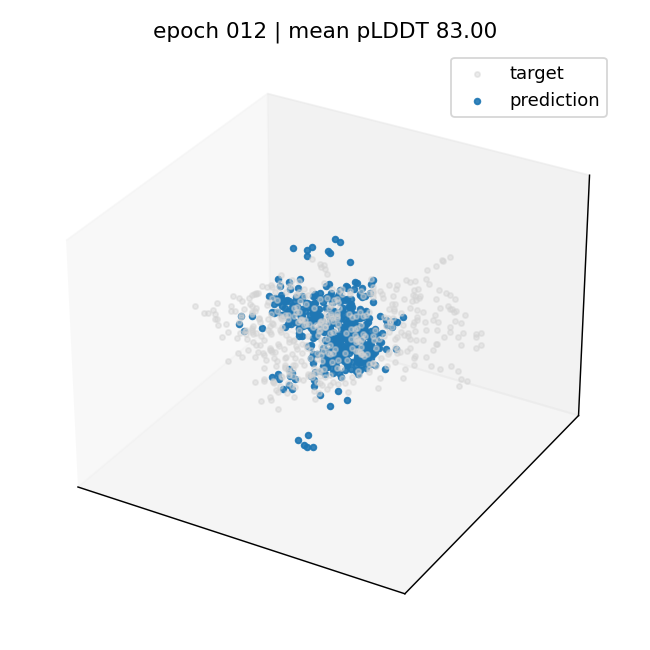

epoch 13 | train loss 5.9324 | val loss 6.3246 | diff 4.4973 | dist 1.3158 | dgram 2.8457 | conf 2.0805


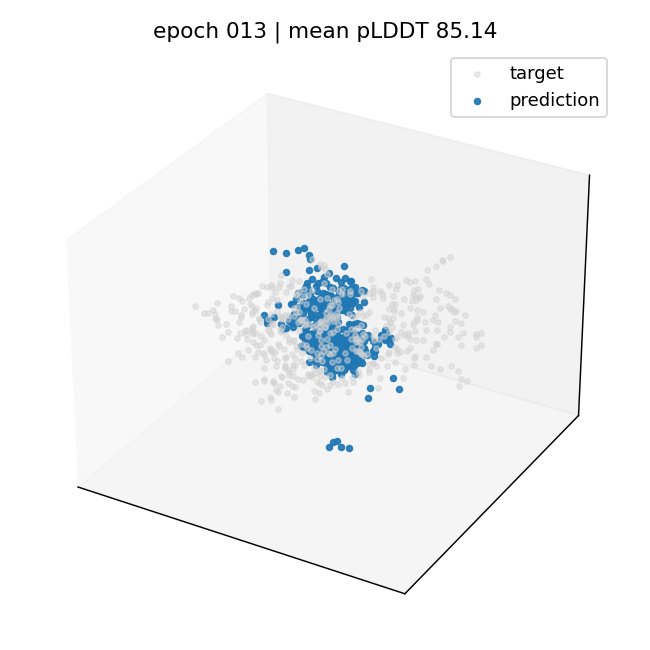

epoch 14 | train loss 5.1434 | val loss 7.3672 | diff 3.7788 | dist 1.2024 | dgram 2.8481 | conf 1.9371


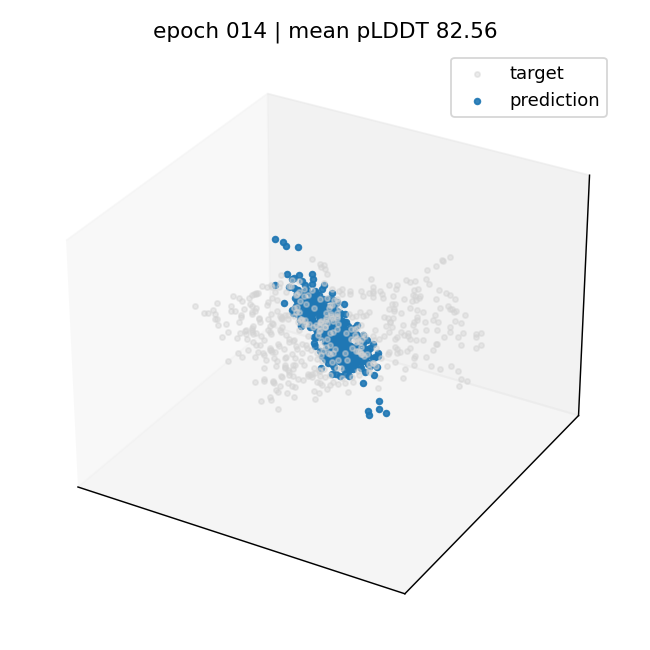

epoch 15 | train loss 6.7421 | val loss 6.0358 | diff 5.1830 | dist 1.5592 | dgram 2.8404 | conf 2.1143


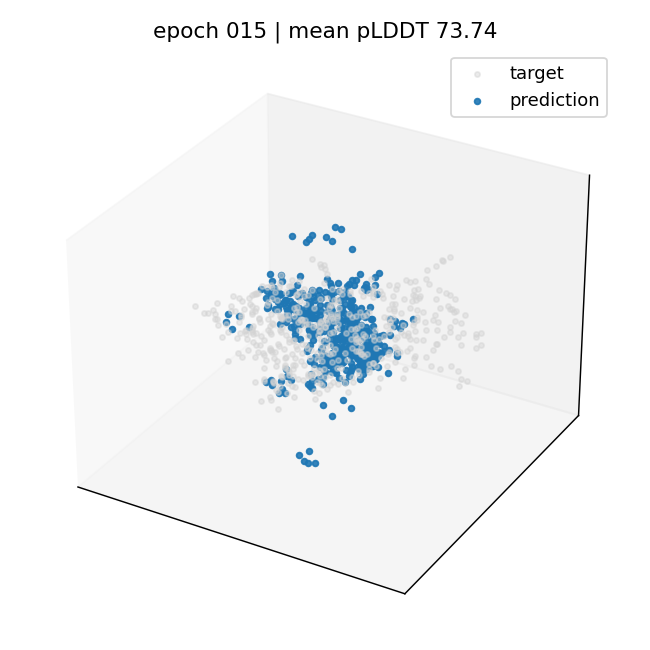

epoch 16 | train loss 5.2106 | val loss 6.0393 | diff 3.8810 | dist 1.1789 | dgram 2.8037 | conf 1.7945


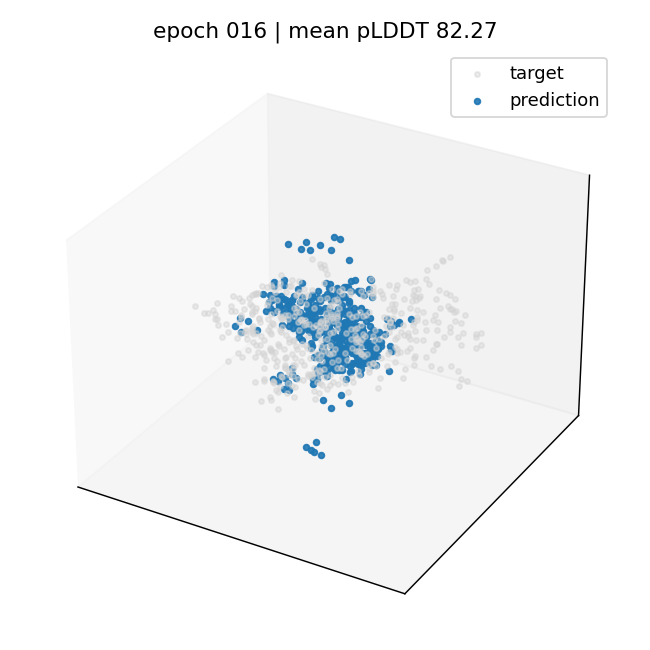

epoch 17 | train loss 7.2441 | val loss 6.3495 | diff 5.6201 | dist 1.6836 | dgram 2.8078 | conf 2.2063


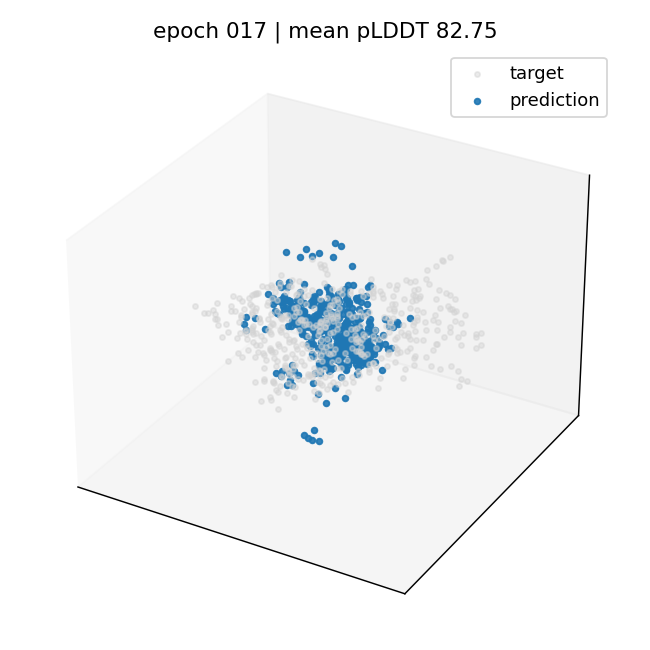

epoch 18 | train loss 5.9043 | val loss 6.3662 | diff 4.5214 | dist 1.2920 | dgram 2.7789 | conf 1.8106


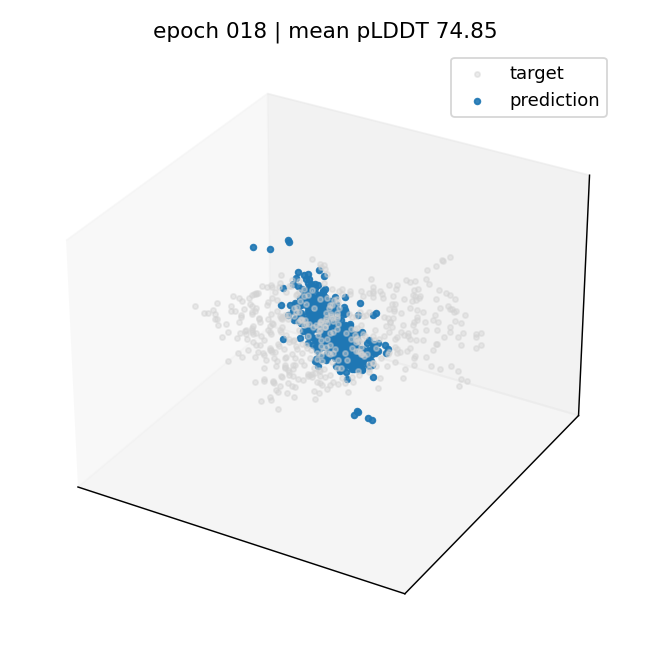

epoch 19 | train loss 4.6538 | val loss 6.2074 | diff 3.3957 | dist 1.0478 | dgram 2.7833 | conf 1.7749


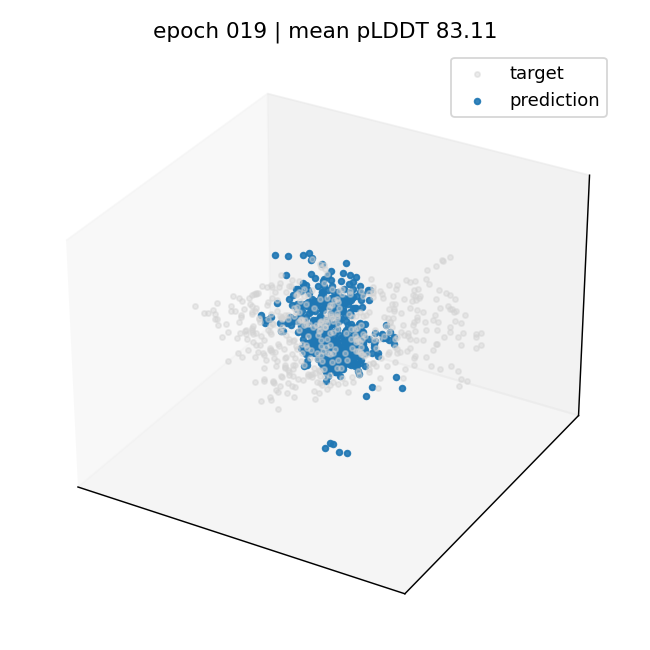

epoch 20 | train loss 5.7960 | val loss 6.2263 | diff 4.4304 | dist 1.2422 | dgram 2.7898 | conf 1.8658


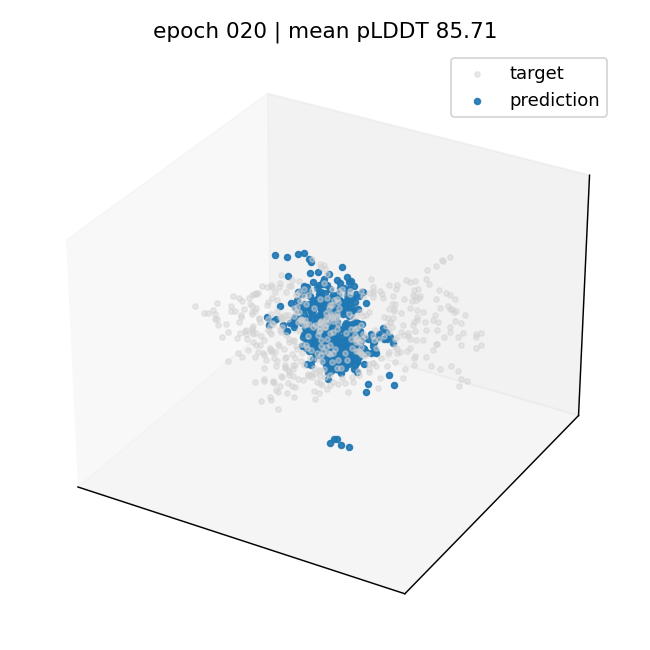

epoch 21 | train loss 6.2021 | val loss 6.1226 | diff 4.7804 | dist 1.3818 | dgram 2.7331 | conf 1.8422


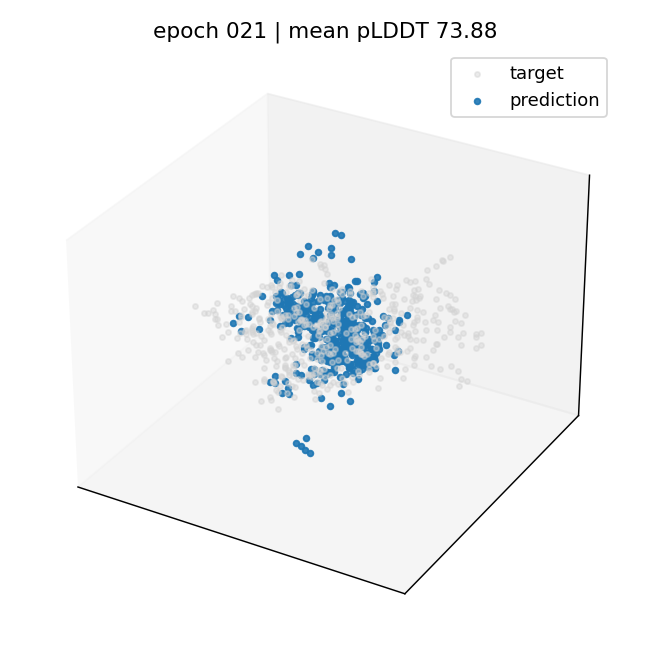

epoch 22 | train loss 5.2987 | val loss 6.1531 | diff 4.0739 | dist 1.0363 | dgram 2.6983 | conf 1.6703


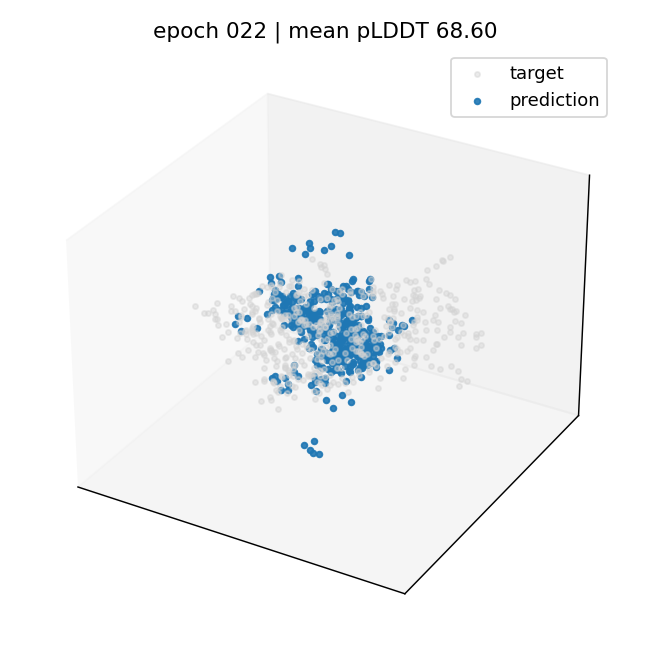

epoch 23 | train loss 6.0645 | val loss 6.0407 | diff 4.6894 | dist 1.3090 | dgram 2.7047 | conf 1.7967


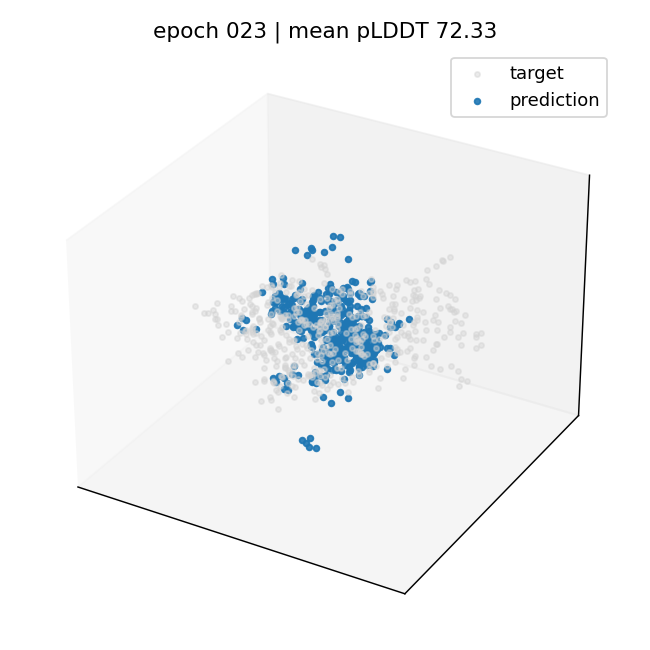

epoch 24 | train loss 4.8262 | val loss 6.2759 | diff 3.5471 | dist 1.1322 | dgram 2.7251 | conf 1.6794


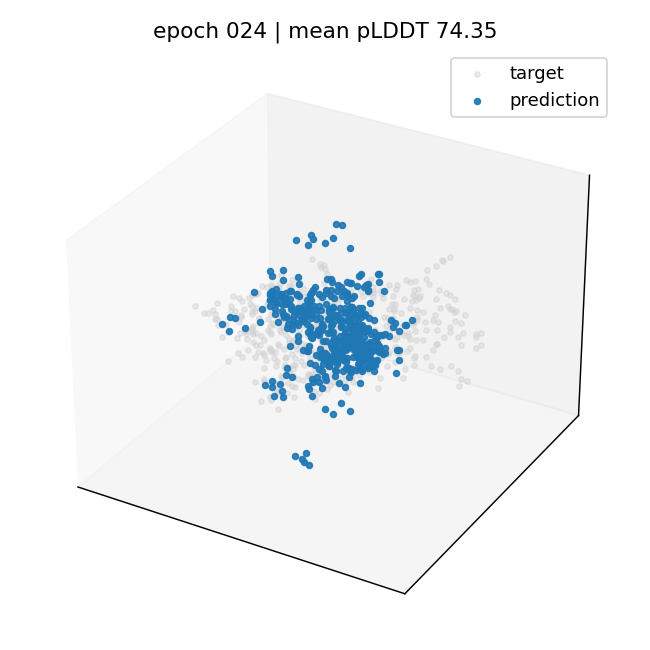

epoch 25 | train loss 4.8987 | val loss 6.0606 | diff 3.6164 | dist 1.1474 | dgram 2.6599 | conf 1.7666


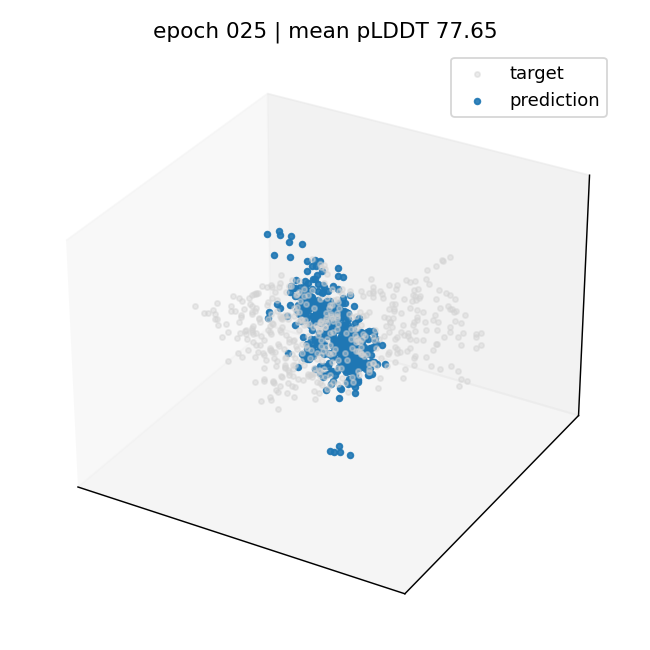

saved checkpoint: /Users/djemec/data/protein_folding/checkpoint/protein_folding_folding.pt


In [12]:
for step in range(1, max_steps + 1):
    batch = train_loader.next_batch(device)
    output = model(
        **folding_model_inputs(batch),
        target_atom_coords=batch['atom_coords'],
    )
    loss = output['loss']

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        1.0,
    )
    optimizer.step()

    loss_value = float(loss.item())
    loss_history.append(loss_value)
    train_loss_total += loss_value
    for name, value in output['losses'].items():
        if value is not None:
            train_component_total[name] += float(value.item())

    if step % steps_per_epoch == 0:
        epoch = step // steps_per_epoch
        model.eval()
        model.protein_lm.eval()
        val_loader.reset()
        validation_generator = torch.Generator(device=device).manual_seed(SEED + 10_000)
        val_loss_total = 0.0
        val_component_total = {
            'diffusion': 0.0,
            'distance': 0.0,
            'distogram': 0.0,
            'confidence': 0.0,
        }
        with torch.no_grad():
            for _ in range(val_steps):
                batch = val_loader.next_batch(device)
                sigma = sample_log_uniform_sigmas(
                    batch['atom_coords'],
                    folding_cfg.sigma_min,
                    folding_cfg.sigma_max,
                    generator=validation_generator,
                )
                noise = centered_gaussian_noise(
                    batch['atom_coords'],
                    batch['atom_attention_mask'],
                    generator=validation_generator,
                )
                output = model(
                    **folding_model_inputs(batch),
                    target_atom_coords=batch['atom_coords'],
                    sigma=sigma,
                    noise=noise,
                )
                val_loss_total += float(output['loss'].item())
                for name, value in output['losses'].items():
                    if value is not None:
                        val_component_total[name] += float(value.item())

        train_loss = train_loss_total / steps_per_epoch
        val_loss = val_loss_total / val_steps
        train_components = {
            name: value / steps_per_epoch
            for name, value in train_component_total.items()
        }
        val_components = {
            name: value / val_steps
            for name, value in val_component_total.items()
        }
        frame_path, pdb_path = save_epoch_structure_frame(epoch)
        frame_history.append((epoch, str(frame_path), str(pdb_path)))
        val_history.append((step, val_loss))
        component_history.append((step, train_components, val_components))

        print(
            f'epoch {epoch:2d} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
            f'diff {train_components["diffusion"]:.4f} | dist {train_components["distance"]:.4f} | '
            f'dgram {train_components["distogram"]:.4f} | conf {train_components["confidence"]:.4f}'
        )
        display(Image(filename=str(frame_path)))

        train_loss_total = 0.0
        train_component_total = {
            'diffusion': 0.0,
            'distance': 0.0,
            'distogram': 0.0,
            'confidence': 0.0,
        }
        model.train()
        model.protein_lm.eval()

torch.save(
    {
        'stage': 'folding_training',
        'model': model.state_dict(),
        'config': folding_cfg.__dict__,
        'step': max_steps,
        'loss_history': loss_history,
        'val_history': val_history,
        'component_history': component_history,
        'frame_history': frame_history,
        'plm_checkpoint': str(plm_checkpoint_path),
    },
    folding_checkpoint_path,
)
print(f'saved checkpoint: {folding_checkpoint_path}')


## Loss Curve

The total loss is useful for the broad training trend. The component history tells us which part of the folding objective is moving: one-step diffusion, representative pair distances, distogram bins, and confidence supervision.


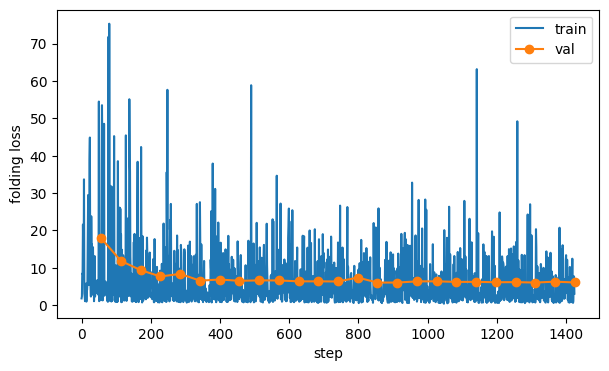

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, label='train')
if val_history:
    steps = [item[0] for item in val_history]
    values = [item[1] for item in val_history]
    plt.plot(steps, values, marker='o', label='val')
plt.xlabel('step')
plt.ylabel('folding loss')
plt.legend()
plt.show()


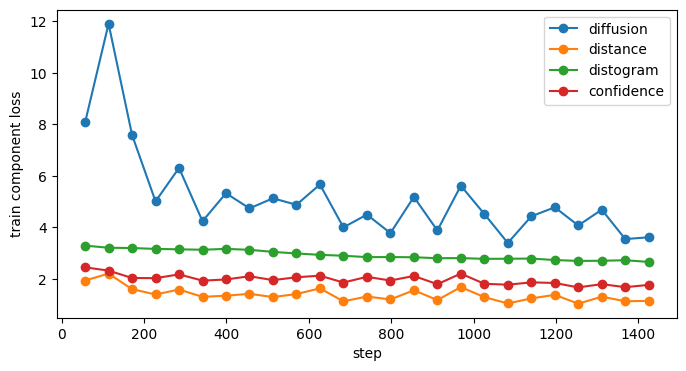

In [14]:
if component_history:
    steps = [item[0] for item in component_history]
    names = ['diffusion', 'distance', 'distogram', 'confidence']
    plt.figure(figsize=(8, 4))
    for name in names:
        plt.plot(steps, [item[1][name] for item in component_history], marker='o', label=name)
    plt.xlabel('step')
    plt.ylabel('train component loss')
    plt.legend()
    plt.show()


## Training GIF

The epoch frames are already saved in `folding_epoch_frames`. This cell stitches them into a GIF after training, using the same frame order as the epoch numbers.


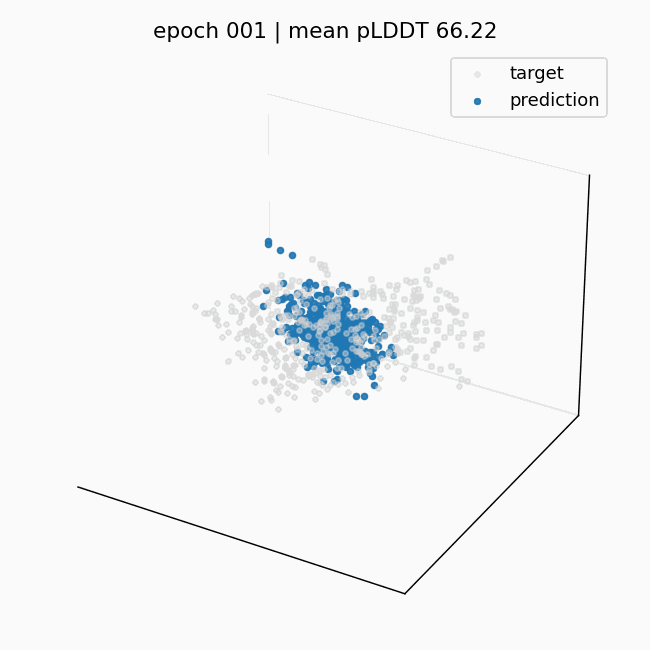

PosixPath('/Users/djemec/data/protein_folding/folding_training_progress.gif')

In [15]:
from PIL import Image as PILImage

frame_files = [Path(item[1]) for item in frame_history]
gif_path = data_root / 'folding_training_progress.gif'
frames = [PILImage.open(path).convert('P') for path in frame_files]
if frames:
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=400,
        loop=0,
    )
    display(Image(filename=str(gif_path)))
gif_path


## Output Tensors

Finally we inspect one validation forward pass. These are the tensors that the next stage and inference path consume: denoised atom coordinates, distogram logits, confidence logits, pLDDT-like confidence, PAE/PDE outputs, and the scalar loss dictionary.


In [16]:
batch = val_loader.next_batch(device)
model.eval()
model.protein_lm.eval()
with torch.no_grad():
    output = model(
        **folding_model_inputs(batch),
        target_atom_coords=batch['atom_coords'],
    )

output['pred_atom_coords'].shape, output['distogram_logits'].shape, output['predicted_plddt'].shape


(torch.Size([2, 2368, 3]), torch.Size([2, 64, 64, 32]), torch.Size([2, 64]))

In [17]:
output['loss'], output['losses']


(tensor(3.1142),
 {'diffusion': tensor(1.9220),
  'distance': tensor(0.8623),
  'distogram': tensor(2.8662),
  'confidence': tensor(1.8780)})

In [18]:
output['pred_atom_coords'].shape, output['pred_atom_coords']


(torch.Size([2, 2368, 3]),
 tensor([[[-13.9939,  -1.0389,  -1.3103],
          [-13.9460,  -0.8530,  -0.6370],
          [-14.6034,   2.6547,  -0.2007],
          ...,
          [  0.0000,  -0.0000,  -0.0000],
          [  0.0000,  -0.0000,  -0.0000],
          [  0.0000,  -0.0000,  -0.0000]],
 
         [[  7.6420,  -3.6168,  -1.1376],
          [  7.8682,  -3.7399,  -1.3993],
          [  7.7282,  -3.6206,  -0.7490],
          ...,
          [ -0.0000,   0.0000,   0.0000],
          [ -0.0000,   0.0000,   0.0000],
          [ -0.0000,   0.0000,   0.0000]]]))

In [19]:
output['predicted_plddt'].shape, output['predicted_plddt']


(torch.Size([2, 64]),
 tensor([[83.4515, 81.9595, 89.0180, 86.9753, 86.7923, 91.3719, 90.9678, 91.1158,
          86.3067, 81.4202, 87.0654, 84.5150, 80.2227, 78.9267, 90.3357, 89.5838,
          88.4348, 82.2523, 87.8427, 88.8737, 81.6746, 91.5246, 86.6475, 88.3963,
          90.5130, 90.6234, 82.0580, 78.6773, 72.6240, 72.6989, 75.5861, 74.0591,
          86.4519, 91.4542, 91.5354, 89.3961, 81.3319, 83.9418, 77.1540, 77.2765,
          85.9670, 74.9786, 80.9122, 91.5479, 86.2563, 86.1153, 76.4683, 77.5152,
          78.1115, 85.7707, 86.1066, 90.4256, 76.6179, 81.3846, 78.2766, 73.6540,
          84.1737, 89.2773,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [83.6217, 86.4605, 77.8244, 71.8439, 71.8145, 90.5397, 70.9250, 71.8997,
          78.8891, 72.9367, 75.2883, 86.1500, 78.2211, 86.2738, 77.3552, 76.9649,
          76.7283, 78.2670, 76.6558, 86.6196, 84.2320, 78.0378, 74.1407, 75.4653,
          79.7897, 79.1407, 80.5720, 87.3635, 74.6568, 75.5667, 83.0375, 84